In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score 
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import category_encoders as ce
from scipy.stats import ttest_rel 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Считываем файлы
files = {
    'audi': 'cars/audi.csv',
    'bmw': 'cars/bmw.csv',
    'cclass': 'cars/cclass.csv',
    'focus': 'cars/focus.csv',
    'ford': 'cars/ford.csv',
    'hyundi': 'cars/hyundi.csv',    
    'merc': 'cars/merc.csv',
    'skoda': 'cars/skoda.csv',    
    'toyota': 'cars/toyota.csv',    
    'vauxhall': 'cars/vauxhall.csv',    
    'vw': 'cars/vw.csv'
}
# Список для хранения датафреймов
dfs = []
for brand, path in files.items():
    df = pd.read_csv(path)
    df['brand'] = brand
    dfs.append(df)
    
# Объединяем все датафреймы
resultDF = pd.concat(dfs, ignore_index=True)

In [3]:
#1 Проверяю данные
#1.1 Общая информация о данных
print(resultDF.shape)       # Сколько строк и столбцов
print(resultDF.info())      # Типы данных и наличие пропусков

(108540, 11)
<class 'pandas.DataFrame'>
RangeIndex: 108540 entries, 0 to 108539
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model         108540 non-null  str    
 1   year          108540 non-null  int64  
 2   price         108540 non-null  int64  
 3   transmission  108540 non-null  str    
 4   mileage       108540 non-null  int64  
 5   fuelType      108540 non-null  str    
 6   tax           94327 non-null   float64
 7   mpg           99187 non-null   float64
 8   engineSize    108540 non-null  float64
 9   brand         108540 non-null  str    
 10  tax(£)        4860 non-null    float64
dtypes: float64(4), int64(3), str(4)
memory usage: 9.1 MB
None


In [4]:
# 1.1. Пропуски (NaN)
print("\n--- Пропуски в столбцах ---")
print(resultDF.isnull().sum())


--- Пропуски в столбцах ---
model                0
year                 0
price                0
transmission         0
mileage              0
fuelType             0
tax              14213
mpg               9353
engineSize           0
brand                0
tax(£)          103680
dtype: int64


In [5]:
# 1.2. Проверка на дубликаты
duplicates = resultDF.duplicated().sum()
print(f"\n--- Дубликаты: {duplicates} ---")


--- Дубликаты: 2273 ---


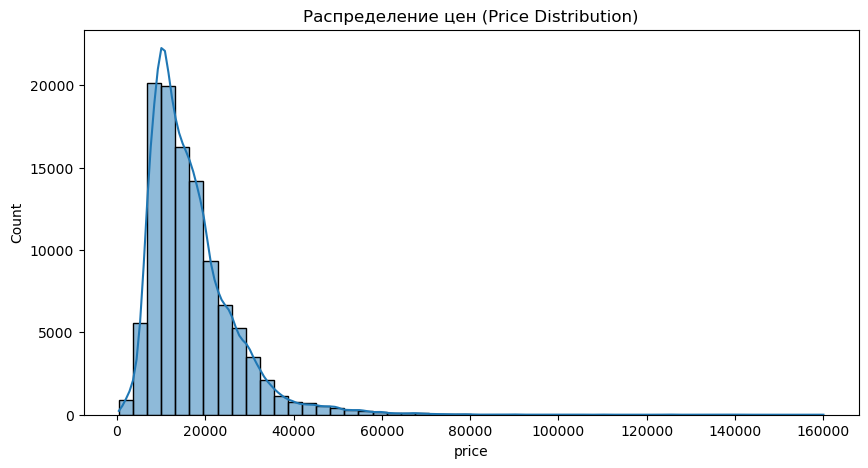

In [6]:
# 1.3. Распределение целевой переменной (Цены)
plt.figure(figsize=(10, 5))
sns.histplot(resultDF['price'], bins=50, kde=True)
plt.title('Распределение цен (Price Distribution)')
plt.show()

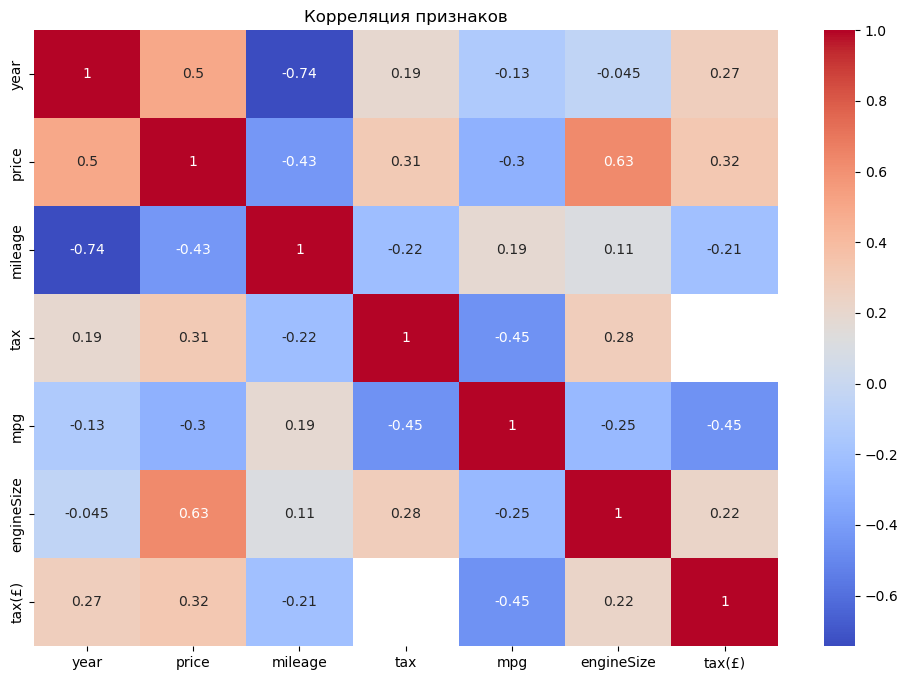

In [7]:
# Смотрим, какие числовые признаки сильнее всего связаны с ценой
plt.figure(figsize=(12, 8))
sns.heatmap(resultDF.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

Вывод: 
year и mileage: Мультиколлинеарность (признаки дублируют друг друга) 
year - важный признак
engineSize - важный признак
mileage  - важный признак
tax имеет корреляцию с price 0.31 (полезный признак)

tax, mpg содержат пустые значения, поэтому после разбиения на группы заполним медианой по группам
tax(£) и tax имеют идентичные корреляции с mpg (-0.45). Это одна и таже информация. Удаляю столбец tax(£) 
И надо удалить дубли
#Мультиколлинеарность для линейной регрессии плохо. Можно создать два новых признака: age и mileage_per_year

In [8]:
resultDF['age'] = 2026 - resultDF['year']
resultDF['mileage_per_year'] = resultDF['mileage'] / resultDF['age'].replace(0, 1)
resultDF = resultDF.drop(columns=['year', 'mileage'])

#'tax(£)' столбец содержит значения только для hyundi, значит он не информативен для модели
resultDF = resultDF.drop(columns=['tax(£)'])



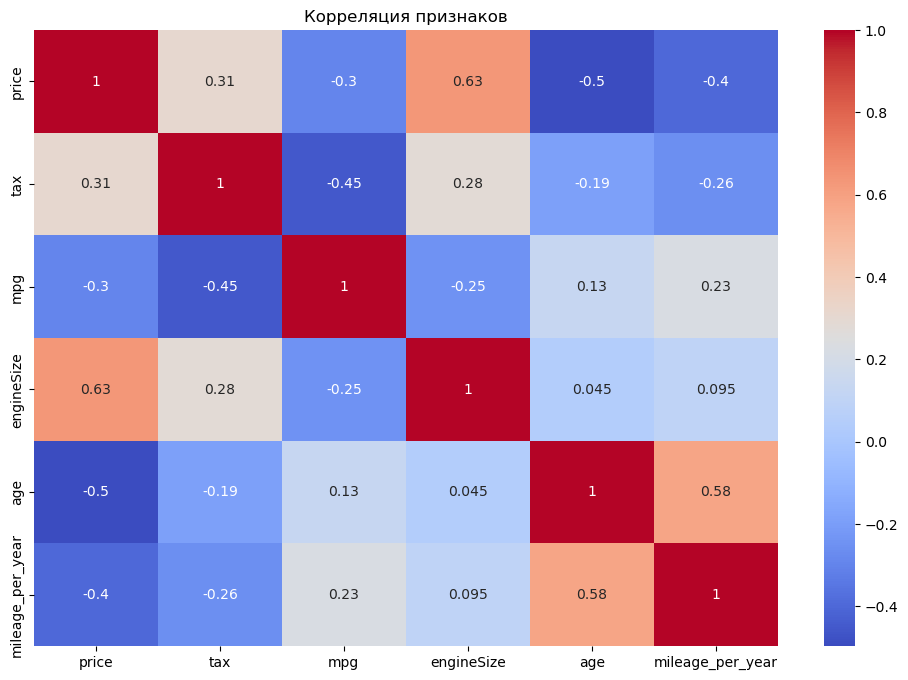

In [9]:
# Смотрим, какие числовые признаки сильнее всего связаны с ценой
plt.figure(figsize=(12, 8))
sns.heatmap(resultDF.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

In [10]:
#Убираю дубликаты
resultDF = resultDF.drop_duplicates()

In [11]:
#Изучаем категориальные признаки
cat_cols = ['fuelType', 'transmission', 'model']  # замените на ваши названия

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(f"Уникальных значений: {resultDF[col].nunique()}")
    print(f"Пропуски: {resultDF[col].isnull().sum()}")
    #print("\nТоп-10 значений:")
    #print(resultDF[col].value_counts().head(10))
    print("\nРаспределение (%):")
    print(resultDF[col].value_counts(normalize=True).head(10) * 100)


=== fuelType ===
Уникальных значений: 5
Пропуски: 0

Распределение (%):
fuelType
Petrol      54.994871
Diesel      41.741405
Hybrid       3.020921
Other        0.237156
Electric     0.005647
Name: proportion, dtype: float64

=== transmission ===
Уникальных значений: 4
Пропуски: 0

Распределение (%):
transmission
Manual       56.312406
Semi-Auto    23.026755
Automatic    20.651427
Other         0.009411
Name: proportion, dtype: float64

=== model ===
Уникальных значений: 195
Пропуски: 0

Распределение (%):
model
Focus       8.764434
C Class     7.049756
Fiesta      6.125599
Golf        4.514441
Corsa       3.091503
Polo        3.052918
Astra       2.498612
A Class     2.328273
3 Series    2.290629
Kuga        2.077942
Name: proportion, dtype: float64


In [12]:
# fuelType: объединяем Electric и Other - группируем редкие признаки
resultDF['fuelType'] = resultDF['fuelType'].replace(
    ['Electric', 'Other'], 'Other'
)

Разделение на train и test

In [13]:
X = resultDF.drop(columns='price')
y = resultDF['price']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,  random_state = 42)

# проверяем на незаполненность данных и заполняем медианной по группам (по fuelType)
num_cols = ['tax', 'mpg']
group_col = 'fuelType'


for col in num_cols:
    if col in X_train.columns:
        # Заполняем train по группам
        X_train[col] = X_train[col].fillna(
            X_train.groupby(group_col)[col].transform('median')
        )
        
        # Заполняем test по группам (медианы из train!)
        train_medians = X_train.groupby(group_col)[col].median()
        X_test[col] = X_test[col].fillna(
            X_test[group_col].map(train_medians)
        )
        
        # Если остались пропуски — заполнить общей медианой
        X_train[col] = X_train[col].fillna(X_train[col].median())
        X_test[col] = X_test[col].fillna(X_train[col].median())

# Проверка
print(f"Пропусков осталось: {X_train[num_cols].isnull().sum().sum() + X_test[num_cols].isnull().sum().sum()}")

Пропусков осталось: 0


In [15]:
import category_encoders as ce

# Вместо OneHotEncoder использую TargetEncoder
# Заменяем категорию на среднее значение целевой переменной. Помогает избежать создания огромного числа столбцов
#encoder = ce.one_hot.OneHotEncoder(cols=['model', 'transmission', 'fuelType', 'brand'])
    
encoder = ce.TargetEncoder(cols=['model', 'transmission', 'fuelType', 'brand'])
X_train = encoder.fit_transform(X_train, y_train)  
X_test = encoder.transform(X_test)

print(f"После Target Encoding: {X_train.shape[1]} столбцов")

После Target Encoding: 9 столбцов


In [16]:
X_train.head(10)

,model,transmission,fuelType,tax,mpg,engineSize,brand,age,mileage_per_year
108539,14326.312065,12158.695867,14987.452893,145.0,46.3,1.2,16812.121642,19,3894.736842
34389,10208.720162,12158.695867,14987.452893,145.0,65.7,1.0,12283.764997,9,2477.222222
77774,7914.999353,12158.695867,14987.452893,150.0,68.9,1.0,12602.130752,8,1222.125000
5299,17398.735632,12158.695867,14987.452893,20.0,61.4,1.4,22801.481819,9,3321.222222
77373,7914.999353,12158.695867,14987.452893,145.0,69.0,1.0,12602.130752,9,1998.555556
74611,10617.942687,12158.695867,14987.452893,30.0,58.0,1.3,12602.130752,9,3211.555556
5840,22792.894597,24224.602482,14987.452893,150.0,47.9,1.4,22801.481819,9,1666.666667
67945,8333.069491,12158.695867,19163.167407,0.0,67.3,1.6,14270.978805,10,3741.200000
37139,5219.304269,12158.695867,14987.452893,30.0,57.7,1.2,12283.764997,11,1173.181818
35548,15765.870913,12158.695867,19163.167407,145.0,45.6,1.5,12283.764997,7,1566.714286


Данные подготовлены

In [17]:
# Модель 1 - SGDRegressor
from sklearn.model_selection import GridSearchCV, KFold
#scaler_y = StandardScaler()
#y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
#y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

pipe_LR = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(random_state=42, tol=1e-4, learning_rate='adaptive',  eta0=0.01))
])

params = {    
    'model__alpha': [0.001, 0.01],
    'model__penalty': ['l2', 'elasticnet'],    
    'model__max_iter': [5000, 10000],
    'model__l1_ratio': [0.15]
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

modelLR = GridSearchCV(pipe_LR, params,  cv=kfold, n_jobs=-1, scoring='r2')

In [18]:
modelLR.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tol=0.0001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01], 'model__l1_ratio': [0.15], 'model__max_iter': [5000, 10000], 'model__penalty': ['l2', 'elasticnet']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [19]:
pipe_LR_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', modelLR.best_estimator_.named_steps['model'])
])

In [20]:
# Предсказание с обратным преобразованием
y_predLR = modelLR.predict(X_test)
 #y_pred = modelLR.predict(X_test)
#y_pred_scaled = modelLR.predict(X_test)
#y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

r2 = r2_score(y_test, y_predLR)
print(f"SGD R²: {r2:.4f}")

SGD R²: 0.8379


In [21]:
# Модель 2 - RandomForestRegressor
pipe_RF = Pipeline([
    ('model', RandomForestRegressor(max_depth=15, random_state=42))
])
params_RF = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 15, None]
}

modelRF = GridSearchCV(pipe_RF, params_RF, cv=kfold, n_jobs=-1, scoring='r2')


In [22]:
modelRF.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [23]:
pipe_RF_best = Pipeline([
    ('model', modelRF.best_estimator_.named_steps['model'])
])

In [24]:
# Модель 3 - LGBMRegressor - ищем наилучшие параметры
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, KFold
pipe_LGBM = Pipeline([
    ('model', LGBMRegressor(random_state=42, verbose=-1))
])

params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100],
    'model__min_child_samples': [10, 20, 30]
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
modelLGBM = GridSearchCV(
    pipe_LGBM, 
    params,
    cv=kfold,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

In [25]:
modelLGBM.fit(X_train, y_train)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [5, 10, ...], 'model__min_child_samples': [10, 20, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, th

In [26]:
pipe_LGBM_best = Pipeline([
    ('model', modelLGBM.best_estimator_.named_steps['model'])
])

In [27]:
# Модель 4- StackingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
stacking_model = StackingRegressor(
    estimators=[
        ('lr', pipe_LR_best),
        ('rf', pipe_RF_best),
        ('lgbm', pipe_LGBM_best)
    ],
    final_estimator=LinearRegression(),  
    cv=kfold,                                
    n_jobs=-1,
    passthrough=False                    
)
    

In [28]:
#Обучаем все модели и рассчитываем метрику r2_score
import time
models = {
    'SGDRegressor': pipe_LR_best,
    'RandomForest': pipe_RF_best,
    'LightGBM': pipe_LGBM_best,
    'Stacking': stacking_model
}

results = []
for name, model in models.items():
    print(f" Обучение {name}...")
    # Время обучения
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start 
    
    # Предсказания
    # Время предсказания
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start

    # Метрики
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R²': r2,
        'Train time (s)': train_time,
        'Predict time (s)': predict_time,
        'Predict time per sample (ms)': predict_time/len(X_test)*1000
    })
    print(f"  R²: {r2:.4f}")
    print(f"  Время обучения: {train_time:.2f} с")
    print(f"  Время предсказания: {predict_time*1000:.2f} мс ({predict_time/len(X_test)*1000:.3f} мс/образец)")

 Обучение SGDRegressor...
  R²: 0.8379
  Время обучения: 1.61 с
  Время предсказания: 2.57 мс (0.000 мс/образец)
 Обучение RandomForest...
  R²: 0.9579
  Время обучения: 16.25 с
  Время предсказания: 287.02 мс (0.014 мс/образец)
 Обучение LightGBM...
  R²: 0.9645
  Время обучения: 0.62 с
  Время предсказания: 50.44 мс (0.002 мс/образец)
 Обучение Stacking...
  R²: 0.9644
  Время обучения: 33.05 с
  Время предсказания: 350.48 мс (0.016 мс/образец)


In [35]:
from sklearn.base import clone
def fit_stacking(X_train, y_train, base_models, final_model):
    # получаем кол-во объектов
    n_samples = X_train.shape[0]              
    #кол-во моделей
    n_base_models = len(base_models)    
    #создаем нулевой массив значений для n_base_models моделей
    train = np.zeros((n_samples, n_base_models))
    #настраиваем кроссвалидаци. На сколько будем делить (n_splits), shuffle=true -перемешиваем данные
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    #пустой списой обученных моделей
    trained_base_models = []
    
    for i, (name, model) in enumerate(base_models):
        print(f" Обучение {name}...")
        model_predictions = np.zeros(n_samples)   
        
        #разбиваем данные X_train  на 5 фолдов
        for train_idx, val_idx in kfold.split(X_train):  
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            #обучаем на чистой модели для этого создается клон
            clmodel = clone(model) 
            clmodel.fit(X_tr, y_tr)            
            y_pr = clmodel.predict(X_val)
            #заполняем model_predictions
            model_predictions[val_idx] = y_pr 
            
            
        train[:, i] = model_predictions        
        # Обучаем финальную модель на мета-признаках
        final_base_model = clone(model)
        final_base_model.fit(X_train, y_train)
        trained_base_models.append((name, final_base_model))

    final_model.fit(train, y_train)
    return trained_base_models, final_model    
    

In [36]:
def predict_stacking(X_test, base_models, final_model):
    n_samples = X_test.shape[0]
    n_base_models = len(base_models)
    
    test_meta = np.zeros((n_samples, n_base_models))
    
    for i, (name, model) in enumerate(base_models):
        test_meta[:, i] = model.predict(X_test)  # Предсказания базовых моделей
    
    predictions = final_model.predict(test_meta)  # Финальное предсказание
    
    return predictions

In [37]:
trained_base_models, final_model_custom = fit_stacking(
    X_train, y_train,  
    base_models=[               # ← было estimators=
        ('lr', pipe_LR_best),
        ('rf', pipe_RF_best),
        ('lgbm', pipe_LGBM_best)
    ],
    final_model=LinearRegression() 
)

y_pred_custom = predict_stacking(X_test, trained_base_models, final_model_custom)
r2_custom = r2_score(y_test, y_pred_custom)
print(f"R² Custom Stacking: {r2_custom:.4f}")


 Обучение lr...
 Обучение rf...
 Обучение lgbm...
R² Custom Stacking: 0.9644
